
=== Average Time (seconds) ===
data_size   20000   40000
threads                  
1          1.1545  4.6429
2          0.5728  2.3531
4          0.2942  1.2096
7          0.1698  0.6816
8          0.1490  0.6129
16         0.0856     NaN
20         0.0705     NaN
40         0.0499     NaN

=== Speedup ===
data_size   20000  40000
threads                 
1           1.000  1.000
2           2.016  1.973
4           3.925  3.839
7           6.798  6.811
8           7.747  7.575
16         13.481    NaN
20         16.368    NaN
40         23.146    NaN


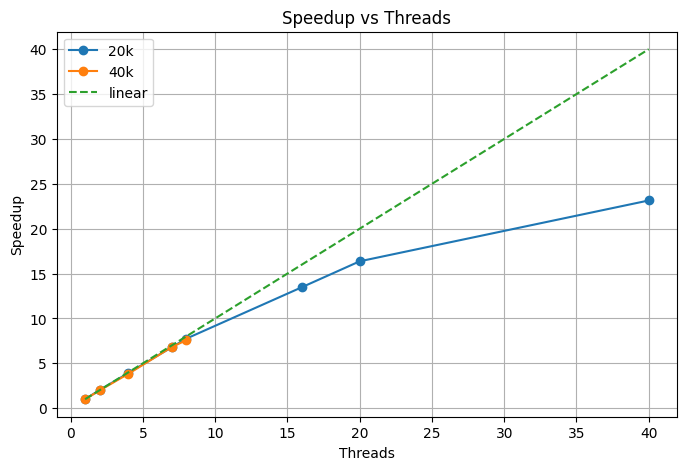

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dgemv/dgemv_time.csv')
df.columns = df.columns.str.strip()

# 1. Очистка выбросов
q10 = df.groupby(['data_size', 'threads'])['time'].transform(lambda x: x.quantile(0.1))
q90 = df.groupby(['data_size', 'threads'])['time'].transform(lambda x: x.quantile(0.9))

df = df[(df['time'] >= q10) & (df['time'] <= q90)]

# 2. Среднее время
df_mean = df.groupby(['data_size', 'threads'])['time'].mean().reset_index()

# 3. Speedup
df_mean['speedup'] = df_mean.groupby('data_size')['time'].transform(lambda x: x.iloc[0] / x)

# 4. Таблицы

print("\n=== Average Time (seconds) ===")
time_table = df_mean.pivot(index='threads', columns='data_size', values='time')
print(time_table.round(4))

print("\n=== Speedup ===")
speedup_table = df_mean.pivot(index='threads', columns='data_size', values='speedup')
print(speedup_table.round(3))

# 5. График

df_20k = df_mean[df_mean['data_size'] == 20000]
df_40k = df_mean[df_mean['data_size'] == 40000]

threads = sorted(df_mean['threads'].unique())
ideal = threads

plt.figure(figsize=(8, 5))

plt.plot(df_20k['threads'], df_20k['speedup'], marker='o', label='20k')
plt.plot(df_40k['threads'], df_40k['speedup'], marker='o', label='40k')
plt.plot(threads, ideal, linestyle='--', label='linear')

plt.xlabel('Threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Threads')
plt.legend()
plt.grid(True)

plt.show()